In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("../data/games.csv")
df.head()

,name,rating,released,genres,platforms,metacritic,playtime,play_mode
0,The Elder Scrolls VI,4.88,NaN,"Action, RPG","PC, Xbox Series S/X",NaN,0,Singleplayer
1,Super Robot Taisen: Original Generation,4.83,2002-11-22,"Strategy, Action",Game Boy Advance,NaN,0,Singleplayer
2,"Warhammer 40,000: Dawn of War - Definitive Edi...",4.83,NaN,NaN,PC,NaN,4,Both
3,No Case Should Remain Unsolved,4.83,2024-01-17,"Indie, Adventure","PC, Nintendo Switch, macOS",NaN,3,Singleplayer
4,Gimmick!,4.83,1992-01-31,NaN,NES,NaN,0,Singleplayer


In [28]:
df = pd.read_csv("../data/games.csv")
df["play_mode"].value_counts()


play_mode
Unknown         452
Singleplayer    341
Both            164
Multiplayer      43
Name: count, dtype: int64

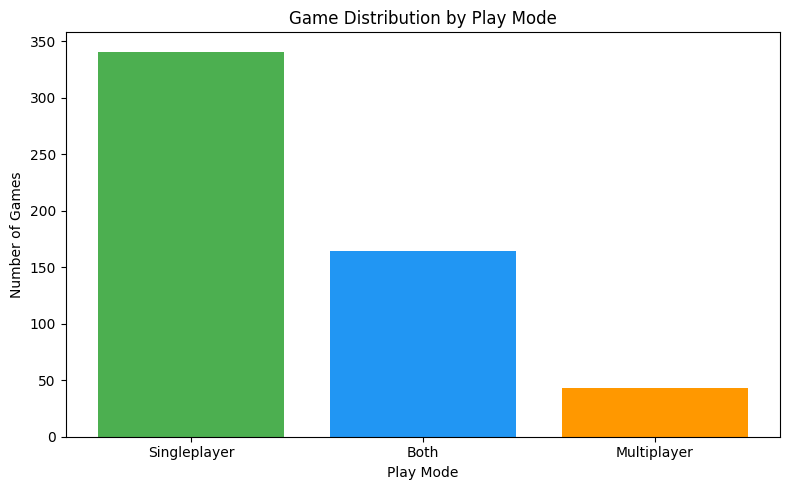

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/games.csv")

# Filter unknowns for play mode
df_play = df[df["play_mode"] != "Unknown"]

# Plot play mode distribution
play_counts = df_play["play_mode"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(play_counts.index, play_counts.values, color=["#4CAF50", "#2196F3", "#FF9800"])
plt.title("Game Distribution by Play Mode")
plt.xlabel("Play Mode")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.show()

In [30]:
# Save raw data including game ID
df = pd.read_csv("../data/games.csv")
unknown = df[df["play_mode"] == "Unknown"][["name"]].head(20)
print(unknown)

                                            name
5        Charlie (Hazbin Hotel) mega porn pack 1
9    Sonic Triple Trouble 16-Bit (NoahNCopeland)
10                           Adventure Island IV
11                                        Arcaea
12                     Nekketsu Kakutou Densetsu
13                              Sengoku Basara 2
14                             Shining Force III
15                                    Bike Baron
18             Championship Manager Season 03/04
21  Attack the Light - Steven Universe Light RPG
22                           Outlast Mobile Demo
23                              Princess Maker 2
25                                     Project M
27                                  Grand Prix 3
28                                     Flattened
32                              Control Resonant
33              siren head simulator (mr bonnie)
34                        One Night at Flumpty's
35                                         Liero
37                  

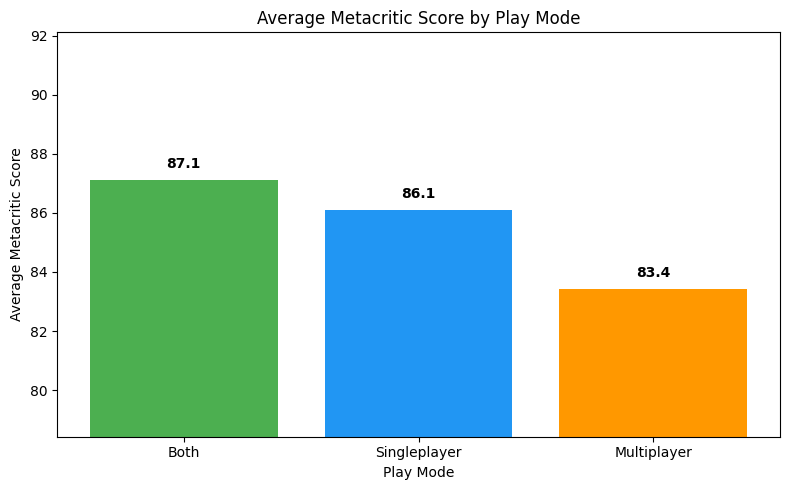

In [33]:
df_meta = df[df["play_mode"] != "Unknown"]
df_meta = df_meta[df_meta["metacritic"] != "N/A"].copy()
df_meta["metacritic"] = pd.to_numeric(df_meta["metacritic"])

avg_meta = df_meta.groupby("play_mode")["metacritic"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_meta.index, avg_meta.values, color=["#4CAF50", "#2196F3", "#FF9800"])

# Add value labels on top of each bar
for bar, val in zip(bars, avg_meta.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f"{val:.1f}", ha="center", va="bottom", fontweight="bold")

plt.title("Average Metacritic Score by Play Mode")
plt.xlabel("Play Mode")
plt.ylabel("Average Metacritic Score")
plt.ylim(avg_meta.min() - 5, avg_meta.max() + 5)  # tight y-axis
plt.tight_layout()
plt.show()

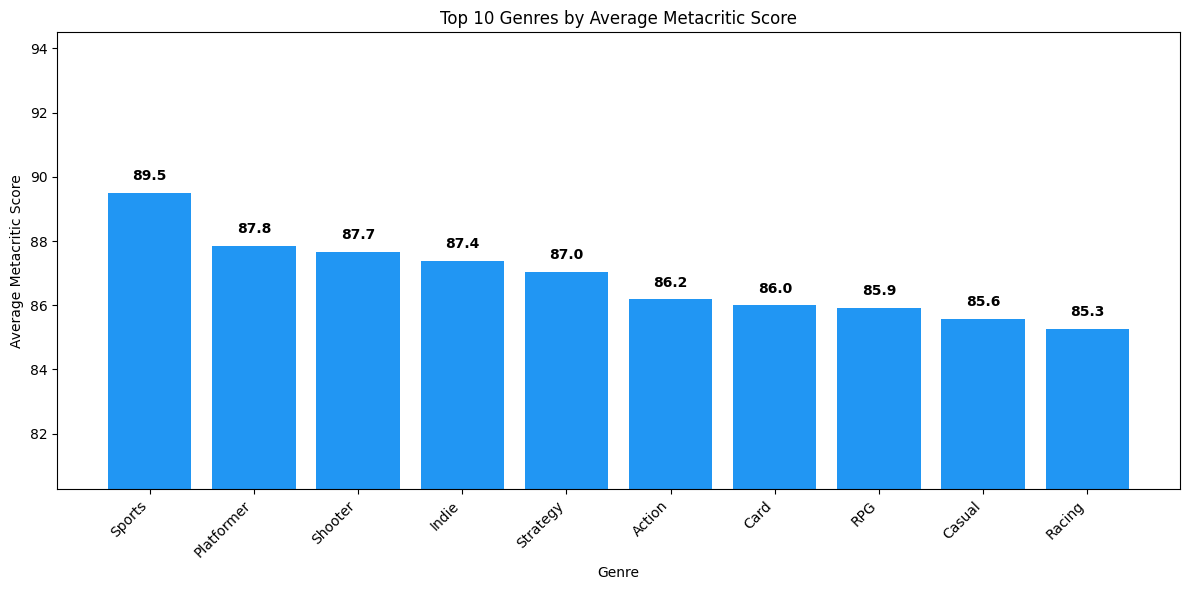

In [34]:
# Filter out N/A metacritic
df_genre = df[df["metacritic"] != "N/A"].copy()
df_genre["metacritic"] = pd.to_numeric(df_genre["metacritic"])

# Split genres (each game can have multiple)
df_genre = df_genre.assign(genres=df_genre["genres"].str.split(", ")).explode("genres")

# Get average metacritic per genre
avg_genre = df_genre.groupby("genres")["metacritic"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.bar(avg_genre.index, avg_genre.values, color="#2196F3")

# Add value labels
for bar, val in zip(bars, avg_genre.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", va="bottom", fontweight="bold")

plt.title("Top 10 Genres by Average Metacritic Score")
plt.xlabel("Genre")
plt.ylabel("Average Metacritic Score")
plt.ylim(avg_genre.min() - 5, avg_genre.max() + 5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [35]:
# Filter sports games
df_sports = df[df["genres"].str.contains("Sports", na=False)][["name", "metacritic", "rating"]].sort_values("metacritic", ascending=False)
print(df_sports.to_string())

                                      name  metacritic  rating
820               Tony Hawk's Pro Skater 3        94.0    4.34
471                                  SSX 3        93.0    4.39
592                 Tony Hawk's Pro Skater        92.0    4.37
427                             SSX Tricky        92.0    4.40
771               Tony Hawk's Pro Skater 2        91.0    4.35
27                            Grand Prix 3        87.0    4.67
721              Tony Hawk's Underground 2        84.0    4.36
468                             Top Spin 4        83.0    4.39
18       Championship Manager Season 03/04         NaN    4.67
93             Online Soccer Manager (OSM)         NaN    4.56
94                            Rush Rally 3         NaN    4.56
118                  Football Manager 2005         NaN    4.50
120            Out of the Park Baseball 19         NaN    4.50
133                             Racket: Nx         NaN    4.50
183                        Sensible Soccer         NaN 

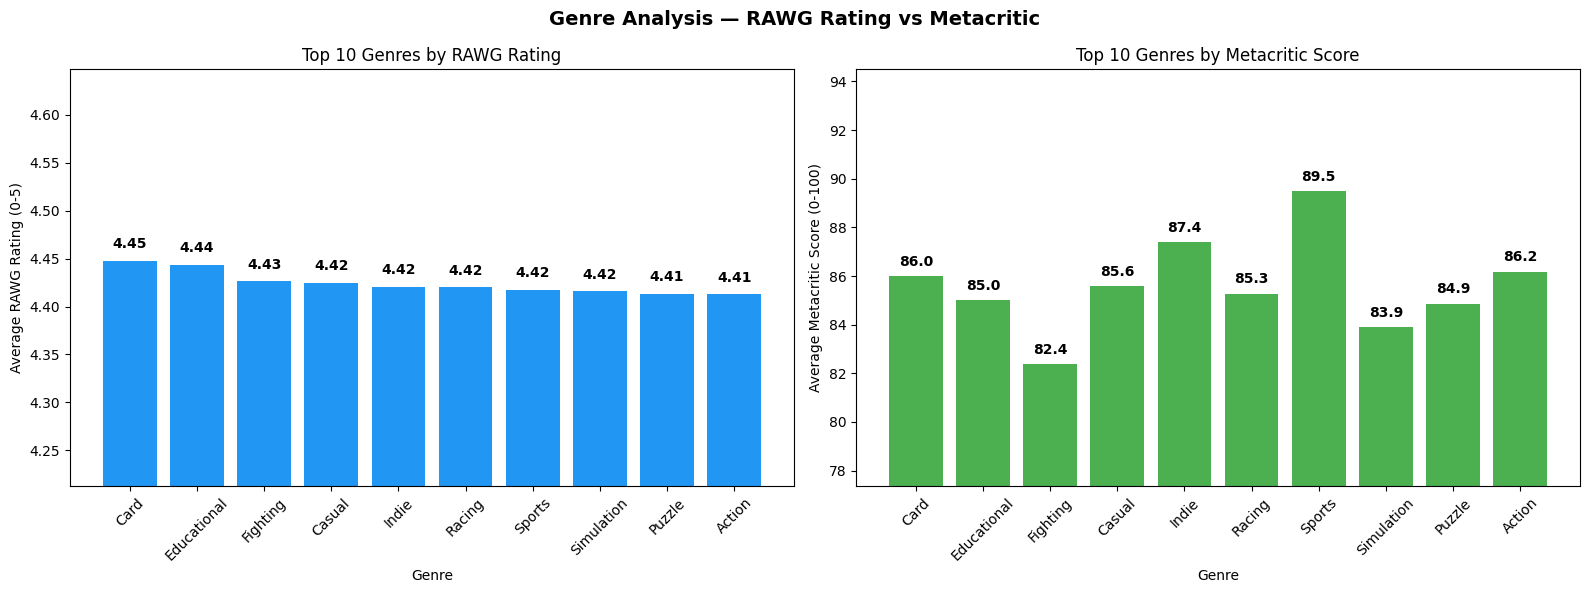

In [36]:
df_genre = df.copy()
df_genre["metacritic"] = pd.to_numeric(df_genre["metacritic"], errors="coerce")
df_genre = df_genre.assign(genres=df_genre["genres"].str.split(", ")).explode("genres")

avg_genre = df_genre.groupby("genres").agg(
    avg_metacritic=("metacritic", "mean"),
    avg_rating=("rating", "mean"),
    count=("name", "count")
).sort_values("avg_rating", ascending=False).head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# RAWG Rating chart
bars1 = ax1.bar(avg_genre.index, avg_genre["avg_rating"], color="#2196F3")
for bar, val in zip(bars1, avg_genre["avg_rating"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
ax1.set_title("Top 10 Genres by RAWG Rating")
ax1.set_xlabel("Genre")
ax1.set_ylabel("Average RAWG Rating (0-5)")
ax1.set_ylim(avg_genre["avg_rating"].min() - 0.2, avg_genre["avg_rating"].max() + 0.2)
ax1.tick_params(axis="x", rotation=45)

# Metacritic chart
bars2 = ax2.bar(avg_genre.index, avg_genre["avg_metacritic"], color="#4CAF50")
for bar, val in zip(bars2, avg_genre["avg_metacritic"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", va="bottom", fontweight="bold")
ax2.set_title("Top 10 Genres by Metacritic Score")
ax2.set_xlabel("Genre")
ax2.set_ylabel("Average Metacritic Score (0-100)")
ax2.set_ylim(avg_genre["avg_metacritic"].min() - 5, avg_genre["avg_metacritic"].max() + 5)
ax2.tick_params(axis="x", rotation=45)

plt.suptitle("Genre Analysis — RAWG Rating vs Metacritic", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

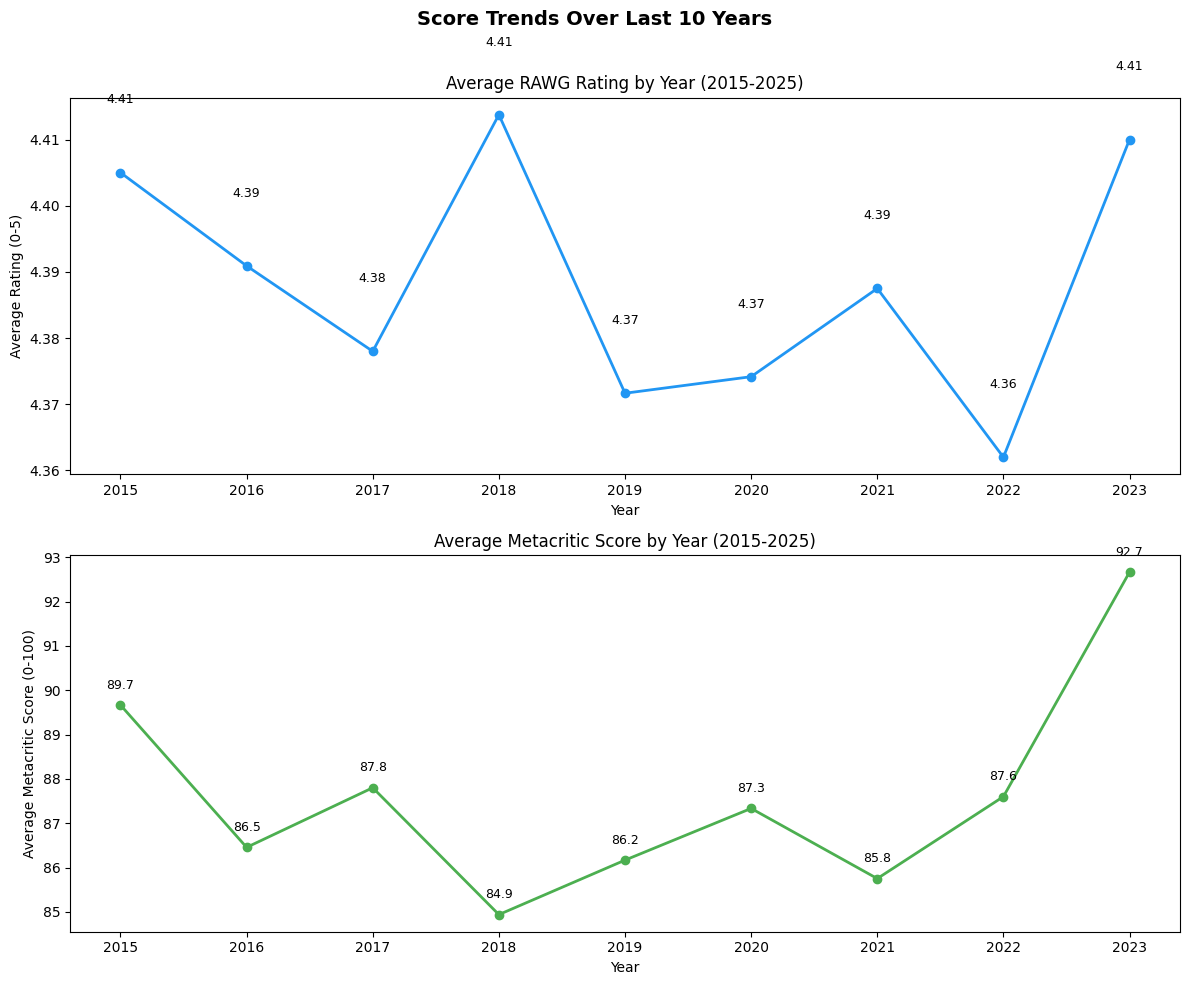

In [37]:
# Convert released to datetime and extract year
df_year = df.copy()
df_year["metacritic"] = pd.to_numeric(df_year["metacritic"], errors="coerce")
df_year["released"] = pd.to_datetime(df_year["released"], errors="coerce")
df_year["year"] = df_year["released"].dt.year

# Filter last 10 years only and drop missing metacritic
df_year = df_year[(df_year["year"] >= 2015) & (df_year["year"] <= 2025)]
df_year = df_year.dropna(subset=["metacritic", "year"])

# Group by year
avg_year = df_year.groupby("year").agg(
    avg_metacritic=("metacritic", "mean"),
    avg_rating=("rating", "mean"),
    count=("name", "count")
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# RAWG Rating trend
ax1.plot(avg_year["year"], avg_year["avg_rating"], marker="o", color="#2196F3", linewidth=2)
for x, y in zip(avg_year["year"], avg_year["avg_rating"]):
    ax1.text(x, y + 0.01, f"{y:.2f}", ha="center", va="bottom", fontsize=9)
ax1.set_title("Average RAWG Rating by Year (2015-2025)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Rating (0-5)")
ax1.set_xticks(avg_year["year"])

# Metacritic trend
ax2.plot(avg_year["year"], avg_year["avg_metacritic"], marker="o", color="#4CAF50", linewidth=2)
for x, y in zip(avg_year["year"], avg_year["avg_metacritic"]):
    ax2.text(x, y + 0.3, f"{y:.1f}", ha="center", va="bottom", fontsize=9)
ax2.set_title("Average Metacritic Score by Year (2015-2025)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Average Metacritic Score (0-100)")
ax2.set_xticks(avg_year["year"])

plt.suptitle("Score Trends Over Last 10 Years", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [38]:
print(df[df["metacritic"] != "N/A"].shape[0])

1000


In [39]:
import pandas as pd

df = pd.read_csv("../data/games.csv")

# Check actual values
print(df["metacritic"].value_counts().head(10))
print(f"\nTotal N/A: {(df['metacritic'] == 'N/A').sum()}")
print(f"Total numeric: {pd.to_numeric(df['metacritic'], errors='coerce').notna().sum()}")

metacritic
85.0    28
88.0    23
83.0    22
91.0    22
92.0    21
84.0    21
90.0    20
86.0    19
94.0    17
93.0    17
Name: count, dtype: int64

Total N/A: 0
Total numeric: 355


In [40]:
# Correct way to check metacritic
df["metacritic"] = pd.to_numeric(df["metacritic"], errors="coerce")
print(f"Games with metacritic: {df['metacritic'].notna().sum()}")
print(f"Games without metacritic: {df['metacritic'].isna().sum()}")

Games with metacritic: 355
Games without metacritic: 645
